<a href="https://colab.research.google.com/github/javisagredo-dev/Evaluacion2_Prog_DS/blob/main/05_aprendizaje_no_supervisado_optimizado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aprendizaje no supervisado: optimización de hiperparámetros

## Importaciones necesarias

In [28]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
from itertools import product
import random
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score, v_measure_score
import time
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

## Carga y lectura de datos

In [29]:
df = pd.read_excel('Dry_Bean_Dataset.xlsx')

## Preparación de datos para optimización de hiperparámetros

In [30]:
df_model = df.copy()

X = df_model.drop('Class', axis=1)
le = LabelEncoder()
y_true = le.fit_transform(df_model['Class'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Carga de las variables guardadas

In [31]:
with open('resultados_no_supervisado.pkl', 'rb') as f:
    datos = pickle.load(f)

ari_km   = datos['ari_km'];   silhouette_km = datos['silhouette_km']
ari_ag   = datos['ari_ag'];   silhouette_ag = datos['silhouette_ag']
ari_db   = datos['ari_db'];   silhouette_db = datos['silhouette_db']
vm_km    = datos['vm_km'];    vm_ag = datos['vm_ag'];    vm_db = datos['vm_db']
y_true   = datos['y_true'];   le    = datos['le']

print("Variables importadas correctamente")
print(f"K-Means base     — ARI: {ari_km:.4f} | Silhouette: {silhouette_km:.4f}")
print(f"Jerárquico base  — ARI: {ari_ag:.4f} | Silhouette: {silhouette_ag:.4f}")
print(f"DBSCAN base      — ARI: {ari_db:.4f} | Silhouette: {silhouette_db:.4f}")

Variables importadas correctamente
K-Means base     — ARI: 0.6686 | Silhouette: 0.3094
Jerárquico base  — ARI: 0.3620 | Silhouette: 0.2282
DBSCAN base      — ARI: 0.1314 | Silhouette: 0.1558


## Grid Search

### Grid Search — K-Means

In [32]:
param_grid_km = {
    'n_clusters': [6, 7, 8],
    'init':       ['k-means++', 'random'],
    'n_init':     [10, 20],
    'max_iter':   [300, 500]
}

start_time = time.time()
best_ari_gs_km = -1
best_params_gs_km = None

for n_c, ini, n_i, m_i in product(param_grid_km['n_clusters'],
                                   param_grid_km['init'],
                                   param_grid_km['n_init'],
                                   param_grid_km['max_iter']):
    km = KMeans(n_clusters=n_c, init=ini, n_init=n_i, max_iter=m_i, random_state=42)
    lbl = km.fit_predict(X_scaled)
    ari = adjusted_rand_score(y_true, lbl)
    if ari > best_ari_gs_km:
        best_ari_gs_km = ari
        best_params_gs_km = {'n_clusters': n_c, 'init': ini, 'n_init': n_i, 'max_iter': m_i}

time_gs_km = time.time() - start_time

km_gs = KMeans(**best_params_gs_km, random_state=42)
labels_gs_km = km_gs.fit_predict(X_scaled)
sil_gs_km = silhouette_score(X_scaled, labels_gs_km)
ari_gs_km = adjusted_rand_score(y_true, labels_gs_km)

resultados = pd.DataFrame({
    'Métrica': ['Mejores parámetros', 'ARI', 'Silhouette Score', 'Tiempo'],
    'Valor': [str(best_params_gs_km), f"{ari_gs_km:.4f}", f"{sil_gs_km:.4f}", f"{time_gs_km:.2f}s"]
})
display(resultados)

,Métrica,Valor
0,Mejores parámetros,"{'n_clusters': 8, 'init': 'k-means++', 'n_init..."
1,ARI,0.6999
2,Silhouette Score,0.3031
3,Tiempo,3.54s


### Grid Search — Agrupamiento Jerárquico

In [33]:
param_grid_ag = {
    'n_clusters': [6, 7, 8],
    'linkage':    ['ward', 'complete', 'average']
}

start_time = time.time()
best_ari_gs_ag = -1
best_params_gs_ag = None

for n_c, link in product(param_grid_ag['n_clusters'], param_grid_ag['linkage']):
    ag = AgglomerativeClustering(n_clusters=n_c, linkage=link)
    lbl = ag.fit_predict(X_scaled)
    ari = adjusted_rand_score(y_true, lbl)
    if ari > best_ari_gs_ag:
        best_ari_gs_ag = ari
        best_params_gs_ag = {'n_clusters': n_c, 'linkage': link}

time_gs_ag = time.time() - start_time

ag_gs = AgglomerativeClustering(**best_params_gs_ag)
labels_gs_ag = ag_gs.fit_predict(X_scaled)
sil_gs_ag = silhouette_score(X_scaled, labels_gs_ag)
ari_gs_ag = adjusted_rand_score(y_true, labels_gs_ag)

resultados = pd.DataFrame({
    'Métrica': ['Mejores parámetros', 'ARI', 'Silhouette Score', 'Tiempo'],
    'Valor': [str(best_params_gs_ag), f"{ari_gs_ag:.4f}", f"{sil_gs_ag:.4f}", f"{time_gs_ag:.2f}s"]
})
display(resultados)

,Métrica,Valor
0,Mejores parámetros,"{'n_clusters': 8, 'linkage': 'ward'}"
1,ARI,0.7054
2,Silhouette Score,0.2738
3,Tiempo,37.68s


### Grid Search — DBSCAN

In [34]:
param_grid_db = {
    'eps':         [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_samples': [5, 10, 15, 20]
}

start_time = time.time()
best_ari_gs_db = -1
best_params_gs_db = None

for eps, ms in product(param_grid_db['eps'], param_grid_db['min_samples']):
    db = DBSCAN(eps=eps, min_samples=ms)
    lbl = db.fit_predict(X_scaled)
    n_cl = len(set(lbl)) - (1 if -1 in lbl else 0)
    mask = lbl != -1
    if n_cl >= 2 and mask.sum() > 1:
        ari = adjusted_rand_score(y_true[mask], lbl[mask])
        if ari > best_ari_gs_db:
            best_ari_gs_db = ari
            best_params_gs_db = {'eps': eps, 'min_samples': ms}

time_gs_db = time.time() - start_time

db_gs = DBSCAN(**best_params_gs_db)
labels_gs_db = db_gs.fit_predict(X_scaled)
mask_gs_db = labels_gs_db != -1
sil_gs_db = silhouette_score(X_scaled[mask_gs_db], labels_gs_db[mask_gs_db])
ari_gs_db = adjusted_rand_score(y_true[mask_gs_db], labels_gs_db[mask_gs_db])

resultados = pd.DataFrame({
    'Métrica': ['Mejores parámetros', 'ARI', 'Silhouette Score', 'Tiempo'],
    'Valor': [str(best_params_gs_db), f"{ari_gs_db:.4f}", f"{sil_gs_db:.4f}", f"{time_gs_db:.2f}s"]
})
display(resultados)

,Métrica,Valor
0,Mejores parámetros,"{'eps': 0.7, 'min_samples': 15}"
1,ARI,0.2639
2,Silhouette Score,0.3136
3,Tiempo,2.76s


## Random Search

### Random Search — K-Means

In [35]:
param_dist_km = {
    'n_clusters': [5, 6, 7, 8, 9],
    'init':       ['k-means++', 'random'],
    'n_init':     [5, 10, 20, 30],
    'max_iter':   [200, 300, 500]
}

random.seed(42)
n_iter = 20
start_time = time.time()
best_ari_rs_km = -1
best_params_rs_km = None

for _ in range(n_iter):
    params = {k: random.choice(v) for k, v in param_dist_km.items()}
    km = KMeans(**params, random_state=42)
    lbl = km.fit_predict(X_scaled)
    ari = adjusted_rand_score(y_true, lbl)
    if ari > best_ari_rs_km:
        best_ari_rs_km = ari
        best_params_rs_km = params

time_rs_km = time.time() - start_time

km_rs = KMeans(**best_params_rs_km, random_state=42)
labels_rs_km = km_rs.fit_predict(X_scaled)
sil_rs_km = silhouette_score(X_scaled, labels_rs_km)
ari_rs_km = adjusted_rand_score(y_true, labels_rs_km)

resultados = pd.DataFrame({
    'Métrica': ['Mejores parámetros', 'ARI', 'Silhouette Score', 'Tiempo'],
    'Valor': [str(best_params_rs_km), f"{ari_rs_km:.4f}", f"{sil_rs_km:.4f}", f"{time_rs_km:.2f}s"]
})
display(resultados)

,Métrica,Valor
0,Mejores parámetros,"{'n_clusters': 8, 'init': 'k-means++', 'n_init..."
1,ARI,0.6999
2,Silhouette Score,0.3031
3,Tiempo,2.05s


### Random Search — Agrupamiento Jerárquico

In [36]:
param_dist_ag = {
    'n_clusters': [5, 6, 7, 8, 9],
    'linkage':    ['ward', 'complete', 'average']
}

random.seed(42)
n_iter = 15
start_time = time.time()
best_ari_rs_ag = -1
best_params_rs_ag = None

for _ in range(n_iter):
    params = {k: random.choice(v) for k, v in param_dist_ag.items()}
    ag = AgglomerativeClustering(**params)
    lbl = ag.fit_predict(X_scaled)
    ari = adjusted_rand_score(y_true, lbl)
    if ari > best_ari_rs_ag:
        best_ari_rs_ag = ari
        best_params_rs_ag = params

time_rs_ag = time.time() - start_time

ag_rs = AgglomerativeClustering(**best_params_rs_ag)
labels_rs_ag = ag_rs.fit_predict(X_scaled)
sil_rs_ag = silhouette_score(X_scaled, labels_rs_ag)
ari_rs_ag = adjusted_rand_score(y_true, labels_rs_ag)

resultados = pd.DataFrame({
    'Métrica': ['Mejores parámetros', 'ARI', 'Silhouette Score', 'Tiempo'],
    'Valor': [str(best_params_rs_ag), f"{ari_rs_ag:.4f}", f"{sil_rs_ag:.4f}", f"{time_rs_ag:.2f}s"]
})
display(resultados)

,Métrica,Valor
0,Mejores parámetros,"{'n_clusters': 9, 'linkage': 'ward'}"
1,ARI,0.6783
2,Silhouette Score,0.2645
3,Tiempo,62.79s


### Random Search — DBSCAN

In [37]:
param_dist_db = {
    'eps':         [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2],
    'min_samples': [5, 10, 15, 20, 25]
}

random.seed(42)
n_iter = 20
start_time = time.time()
best_ari_rs_db = -1
best_params_rs_db = None

for _ in range(n_iter):
    params = {k: random.choice(v) for k, v in param_dist_db.items()}
    db = DBSCAN(**params)
    lbl = db.fit_predict(X_scaled)
    n_cl = len(set(lbl)) - (1 if -1 in lbl else 0)
    mask = lbl != -1
    if n_cl >= 2 and mask.sum() > 1:
        ari = adjusted_rand_score(y_true[mask], lbl[mask])
        if ari > best_ari_rs_db:
            best_ari_rs_db = ari
            best_params_rs_db = params

time_rs_db = time.time() - start_time

db_rs = DBSCAN(**best_params_rs_db)
labels_rs_db = db_rs.fit_predict(X_scaled)
mask_rs_db = labels_rs_db != -1
sil_rs_db = silhouette_score(X_scaled[mask_rs_db], labels_rs_db[mask_rs_db])
ari_rs_db = adjusted_rand_score(y_true[mask_rs_db], labels_rs_db[mask_rs_db])

resultados = pd.DataFrame({
    'Métrica': ['Mejores parámetros', 'ARI', 'Silhouette Score', 'Tiempo'],
    'Valor': [str(best_params_rs_db), f"{ari_rs_db:.4f}", f"{sil_rs_db:.4f}", f"{time_rs_db:.2f}s"]
})
display(resultados)

,Métrica,Valor
0,Mejores parámetros,"{'eps': 0.5, 'min_samples': 25}"
1,ARI,0.5400
2,Silhouette Score,0.2845
3,Tiempo,2.81s


## Optuna

### Optuna — K-Means

In [38]:
def objective_km(trial):
    n_clusters = trial.suggest_int('n_clusters', 5, 9)
    init       = trial.suggest_categorical('init', ['k-means++', 'random'])
    n_init     = trial.suggest_int('n_init', 5, 30)
    max_iter   = trial.suggest_int('max_iter', 200, 600)
    km = KMeans(n_clusters=n_clusters, init=init, n_init=n_init, max_iter=max_iter, random_state=42)
    lbl = km.fit_predict(X_scaled)
    return adjusted_rand_score(y_true, lbl)

start_time = time.time()
study_km = optuna.create_study(direction='maximize')
study_km.optimize(objective_km, n_trials=30)
time_op_km = time.time() - start_time

best_params_op_km = study_km.best_params
km_op = KMeans(**best_params_op_km, random_state=42)
labels_op_km = km_op.fit_predict(X_scaled)
sil_op_km = silhouette_score(X_scaled, labels_op_km)
ari_op_km = adjusted_rand_score(y_true, labels_op_km)

resultados = pd.DataFrame({
    'Métrica': ['Mejores parámetros', 'ARI', 'Silhouette Score', 'Tiempo'],
    'Valor': [str(best_params_op_km), f"{ari_op_km:.4f}", f"{sil_op_km:.4f}", f"{time_op_km:.2f}s"]
})
display(resultados)

,Métrica,Valor
0,Mejores parámetros,"{'n_clusters': 8, 'init': 'k-means++', 'n_init..."
1,ARI,0.6999
2,Silhouette Score,0.3031
3,Tiempo,6.35s


### Optuna — Agrupamiento Jerárquico

In [39]:
def objective_ag(trial):
    n_clusters = trial.suggest_int('n_clusters', 5, 9)
    linkage    = trial.suggest_categorical('linkage', ['ward', 'complete', 'average'])
    ag = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
    lbl = ag.fit_predict(X_scaled)
    return adjusted_rand_score(y_true, lbl)

start_time = time.time()
study_ag = optuna.create_study(direction='maximize')
study_ag.optimize(objective_ag, n_trials=30)
time_op_ag = time.time() - start_time

best_params_op_ag = study_ag.best_params
ag_op = AgglomerativeClustering(**best_params_op_ag)
labels_op_ag = ag_op.fit_predict(X_scaled)
sil_op_ag = silhouette_score(X_scaled, labels_op_ag)
ari_op_ag = adjusted_rand_score(y_true, labels_op_ag)

resultados = pd.DataFrame({
    'Métrica': ['Mejores parámetros', 'ARI', 'Silhouette Score', 'Tiempo'],
    'Valor': [str(best_params_op_ag), f"{ari_op_ag:.4f}", f"{sil_op_ag:.4f}", f"{time_op_ag:.2f}s"]
})
display(resultados)

,Métrica,Valor
0,Mejores parámetros,"{'n_clusters': 8, 'linkage': 'ward'}"
1,ARI,0.7054
2,Silhouette Score,0.2738
3,Tiempo,126.56s


### Optuna — DBSCAN

In [40]:
def objective_db(trial):
    eps         = trial.suggest_float('eps', 0.5, 1.5)
    min_samples = trial.suggest_int('min_samples', 5, 30)
    db = DBSCAN(eps=eps, min_samples=min_samples)
    lbl = db.fit_predict(X_scaled)
    n_cl = len(set(lbl)) - (1 if -1 in lbl else 0)
    mask = lbl != -1
    if n_cl < 2 or mask.sum() <= 1:
        return 0.0
    return adjusted_rand_score(y_true[mask], lbl[mask])

start_time = time.time()
study_db = optuna.create_study(direction='maximize')
study_db.optimize(objective_db, n_trials=30)
time_op_db = time.time() - start_time

best_params_op_db = study_db.best_params
db_op = DBSCAN(**best_params_op_db)
labels_op_db = db_op.fit_predict(X_scaled)
mask_op_db = labels_op_db != -1
sil_op_db = silhouette_score(X_scaled[mask_op_db], labels_op_db[mask_op_db])
ari_op_db = adjusted_rand_score(y_true[mask_op_db], labels_op_db[mask_op_db])

resultados = pd.DataFrame({
    'Métrica': ['Mejores parámetros', 'ARI', 'Silhouette Score', 'Tiempo'],
    'Valor': [str(best_params_op_db), f"{ari_op_db:.4f}", f"{sil_op_db:.4f}", f"{time_op_db:.2f}s"]
})
display(resultados)

,Métrica,Valor
0,Mejores parámetros,"{'eps': 0.7798938134005472, 'min_samples': 24}"
1,ARI,0.2777
2,Silhouette Score,0.3575
3,Tiempo,4.41s


## Comparación final: todos los métodos de optimización

In [41]:
comparison_final = pd.DataFrame({
    'Modelo': ['K-Means', 'K-Means', 'K-Means', 'K-Means',
               'Jerárquico', 'Jerárquico', 'Jerárquico', 'Jerárquico',
               'DBSCAN', 'DBSCAN', 'DBSCAN', 'DBSCAN'],
    'Método': ['Base', 'Grid Search', 'Random Search', 'Optuna',
               'Base', 'Grid Search', 'Random Search', 'Optuna',
               'Base', 'Grid Search', 'Random Search', 'Optuna'],
    'ARI': [ari_km,    ari_gs_km, ari_rs_km, ari_op_km,
            ari_ag,    ari_gs_ag, ari_rs_ag, ari_op_ag,
            ari_db,    ari_gs_db, ari_rs_db, ari_op_db],
    'Silhouette': [silhouette_km,    sil_gs_km, sil_rs_km, sil_op_km,
                   silhouette_ag,    sil_gs_ag, sil_rs_ag, sil_op_ag,
                   silhouette_db,    sil_gs_db, sil_rs_db, sil_op_db]
})

display(comparison_final.round(4))

,Modelo,Método,ARI,Silhouette
0,K-Means,Base,0.6686,0.3094
1,K-Means,Grid Search,0.6999,0.3031
2,K-Means,Random Search,0.6999,0.3031
3,K-Means,Optuna,0.6999,0.3031
4,Jerárquico,Base,0.3620,0.2282
5,Jerárquico,Grid Search,0.7054,0.2738
6,Jerárquico,Random Search,0.6783,0.2645
7,Jerárquico,Optuna,0.7054,0.2738
8,DBSCAN,Base,0.1314,0.1558
9,DBSCAN,Grid Search,0.2639,0.3136


## Gráfico comparativo: ARI por modelo y método de optimización

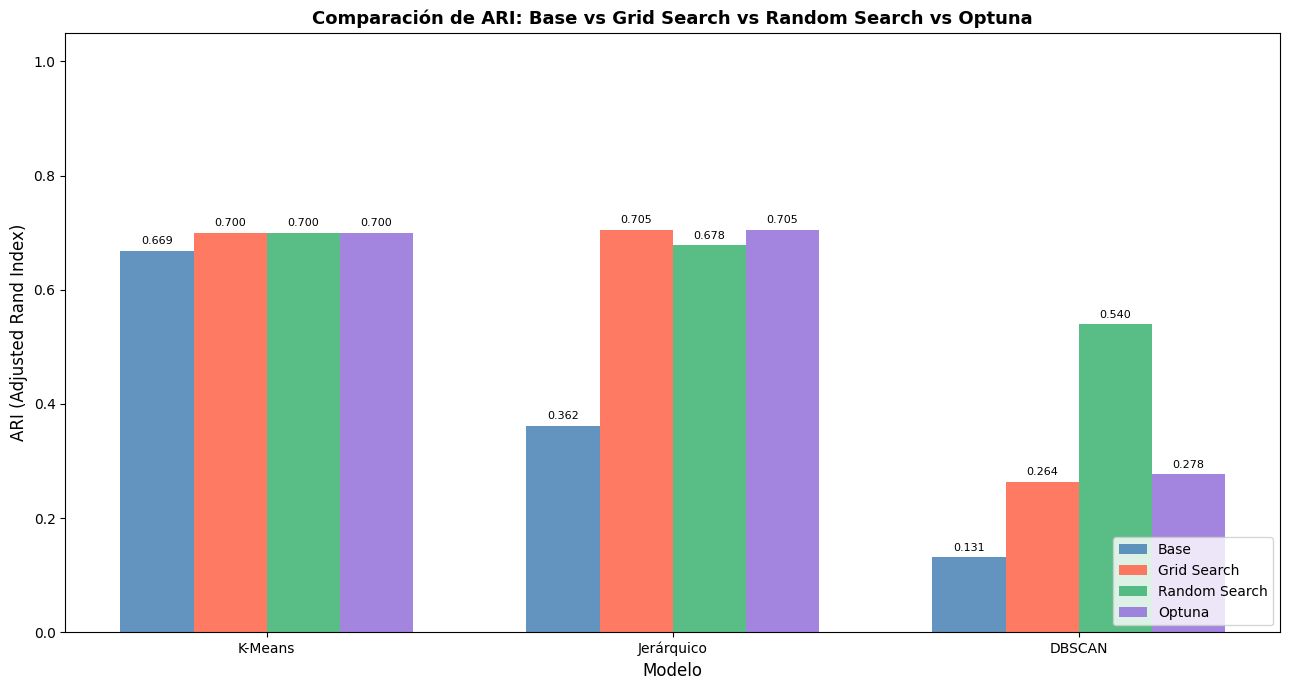

In [42]:
modelos  = ['K-Means', 'Jerárquico', 'DBSCAN']
metodos  = ['Base', 'Grid Search', 'Random Search', 'Optuna']
colores  = ['steelblue', 'tomato', 'mediumseagreen', 'mediumpurple']

ari_values = {
    'Base':         [ari_km,    ari_ag,    ari_db],
    'Grid Search':  [ari_gs_km, ari_gs_ag, ari_gs_db],
    'Random Search':[ari_rs_km, ari_rs_ag, ari_rs_db],
    'Optuna':       [ari_op_km, ari_op_ag, ari_op_db]
}

x     = np.arange(len(modelos))
width = 0.18
fig, ax = plt.subplots(figsize=(13, 7))

for i, (metodo, color) in enumerate(zip(metodos, colores)):
    vals = ari_values[metodo]
    bars = ax.bar(x + (i - 1.5) * width, vals, width, label=metodo, color=color, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('ARI (Adjusted Rand Index)', fontsize=12)
ax.set_title('Comparación de ARI: Base vs Grid Search vs Random Search vs Optuna', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.legend(loc='lower right')
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

## Gráfico comparativo: Silhouette Score por modelo y método de optimización

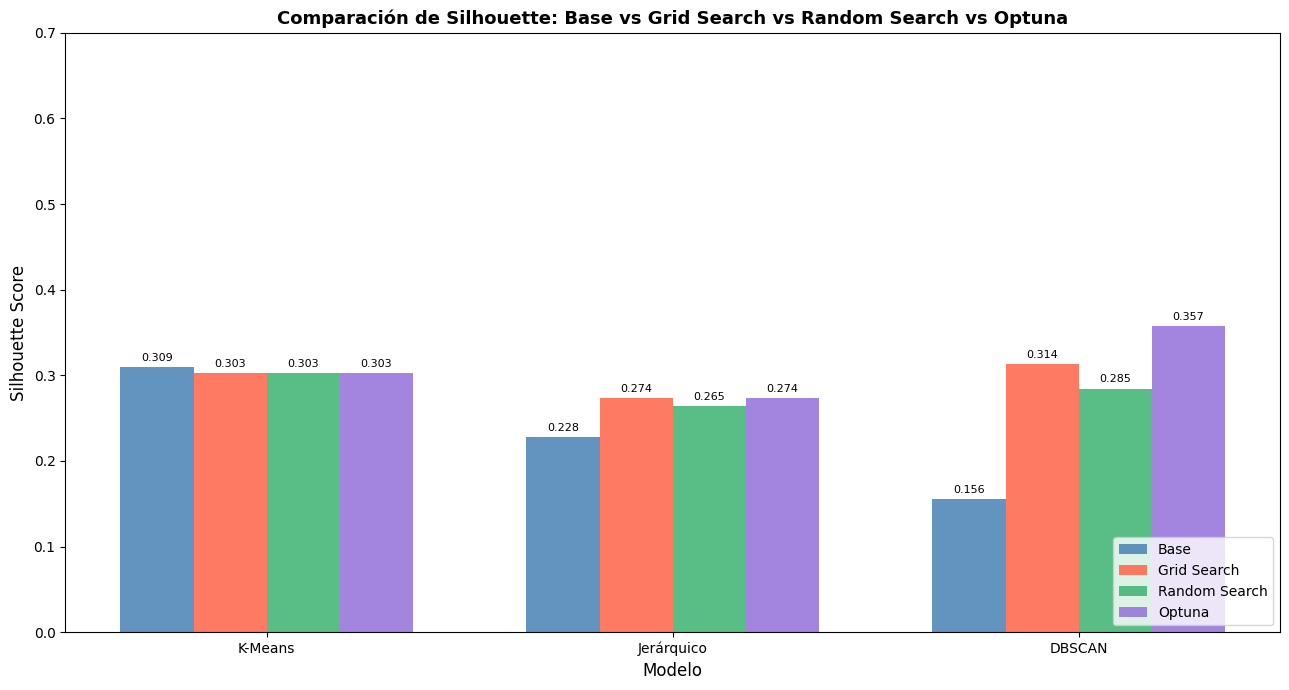

In [43]:
sil_values = {
    'Base':         [silhouette_km,    silhouette_ag,    silhouette_db],
    'Grid Search':  [sil_gs_km, sil_gs_ag, sil_gs_db],
    'Random Search':[sil_rs_km, sil_rs_ag, sil_rs_db],
    'Optuna':       [sil_op_km, sil_op_ag, sil_op_db]
}

fig, ax = plt.subplots(figsize=(13, 7))

for i, (metodo, color) in enumerate(zip(metodos, colores)):
    vals = sil_values[metodo]
    bars = ax.bar(x + (i - 1.5) * width, vals, width, label=metodo, color=color, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Comparación de Silhouette: Base vs Grid Search vs Random Search vs Optuna', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.legend(loc='lower right')
ax.set_ylim([0, 0.7])
plt.tight_layout()
plt.show()